In [2]:
# Standard library imports
import os
import sys
import re
import pickle

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression
from sentence_transformers import SentenceTransformer

# Append parent directory to path for local imports
sys.path.append(os.path.abspath(".."))

# Local application imports
from src.utils.preprocessing import (
    load_clean_data,
    load_content_model,
    load_hybrid_model,
    preprocess_content_text,
    prepare_matrices,
    get_users_for_eval
)
from src.utils.mappings import (
    get_toeic_part_mapping,
    get_subject_categories,
    create_lecture_title
)
from src.evaluation.metrics import (
    precision_at_k,
    recall_at_k,
    rmse_score,
    calculate_precision_recall_at_k,
    calculate_rmse
)

# Set random seed and configurations
np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style="whitegrid", palette="viridis")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Load data
lectures_df, merged_df = load_clean_data()
print(f"Lectures: {len(lectures_df)}, Interactions: {len(merged_df)}")

# Load existing models
content_model = load_content_model('../models/content_based_model_best.pkl')

Loading from paths:
Lectures: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\cleaned_lectures.csv
Merged: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\merged_cleaned_data.csv
Successfully loaded 1021 lectures and 117167 interactions
Lectures: 1021, Interactions: 117167


In [4]:
# Load the hybrid model — now auto-initialized
hybrid_model = load_hybrid_model('../models/svd_hybrid_model_best.pkl')
recommender = hybrid_model['recommender']

In [5]:
# Use it
train_matrix, test_matrix, user_map, item_map = prepare_matrices(merged_df)
reverse_item_map = {v: k for k, v in item_map.items()}
hybrid_model['recommender'].train_matrix = train_matrix

In [6]:
# Prepare bundle features (from notebooks/02_tf_idf.ipynb)
bundle_info = merged_df.groupby('bundle_id').agg({
    'part': 'first',
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),
    'question_id': lambda x: len(set(x))
}).reset_index()
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']
part_names = get_toeic_part_mapping()
bundle_info['part_name'] = bundle_info['part'].map(part_names)
bundle_info['subject_category'] = bundle_info['tags'].apply(lambda x: get_subject_categories(x)[0] if get_subject_categories(x) else "General")
bundle_info['content_text'] = (
    bundle_info['part_name'].fillna('') + ' ' +
    bundle_info['subject_category'].fillna('') + ' ' +
    bundle_info['tags'].fillna('')
)
bundle_info['content_text'] = bundle_info['content_text'].apply(preprocess_content_text)

In [7]:
# Calculate bundle difficulty
bundle_difficulty = merged_df.groupby('bundle_id').apply(
    lambda x: (x['user_answer'] == x['correct_answer']).mean()
).reset_index()
bundle_difficulty.columns = ['bundle_id', 'success_rate']
bundle_info = bundle_info.merge(bundle_difficulty, on='bundle_id', how='left')
bundle_info['success_rate'] = bundle_info['success_rate'].fillna(0.5)

C:\Users\karat\AppData\Local\Temp\ipykernel_8476\863771296.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bundle_difficulty = merged_df.groupby('bundle_id').apply(


In [8]:
# --- Advanced Content-Based Model: Sentence-BERT ---
print("Building Sentence-BERT content-based model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Create rich text representations
bundle_info['rich_text'] = bundle_info.apply(
    lambda x: f"{x['part_name']} focusing on {x['subject_category'].replace('_', ' ')}. Difficulty: {x['success_rate']:.2f}. Tags: {x['tags']}",
    axis=1
)
sbert_embeddings = sbert_model.encode(bundle_info['rich_text'].tolist(), show_progress_bar=True)
sbert_sim = cosine_similarity(sbert_embeddings)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Building Sentence-BERT content-based model...


Batches:   0%|          | 0/259 [00:00<?, ?it/s]

In [9]:
# Recommendation function
def get_sbert_recommendations(user_id, n=10):
    user_history = merged_df[merged_df['user_id'] == user_id]
    seen_bundles = set(user_history['bundle_id'].unique())
    indices = pd.Series(bundle_info.index, index=bundle_info['bundle_id'])
    rec_scores = {}
    for b in seen_bundles:
        if b not in indices:
            continue
        idx = indices[b]
        for i, score in enumerate(sbert_sim[idx]):
            b_id = bundle_info.iloc[i]['bundle_id']
            if b_id not in seen_bundles and score >= 0.1:
                rec_scores[b_id] = rec_scores.get(b_id, 0) + score
    if not rec_scores:
        return []
    max_score = max(rec_scores.values())
    rec_scores = {k: v/max_score for k, v in rec_scores.items()}
    top_bundles = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    enriched_recs = []
    for bundle_id, score in top_bundles:
        row = bundle_info[bundle_info['bundle_id'] == bundle_id].iloc[0]
        enriched_recs.append({
            'bundle_id': bundle_id,
            'score': round(float(score), 4),
            'title': f"{row['part_name']}: {row['subject_category'].replace('_', ' ').title()}",
            'part': row['part_name'],
            'subjects': get_subject_categories(row['tags']),
            'success_rate': row['success_rate']
        })
    return enriched_recs

In [10]:
# --- Advanced Collaborative Filtering: Neural Collaborative Filtering (NCF) ---
print("Building Neural Collaborative Filtering model...")

# Prepare data for NCF
user_counts = merged_df['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
filtered_data = merged_df[merged_df['user_id'].isin(valid_users)]
filtered_data['correct'] = (filtered_data['user_answer'] == filtered_data['correct_answer']).astype(int)
user_item_data = filtered_data.groupby(['user_id', 'bundle_id']).agg(
    correctness_rate=('correct', 'mean'),
    interaction_count=('correct', 'count')
).reset_index()
user_map = {user_id: idx for idx, user_id in enumerate(filtered_data['user_id'].unique())}
item_map = {bundle_id: idx for idx, bundle_id in enumerate(filtered_data['bundle_id'].unique())}
reverse_item_map = {idx: bundle_id for bundle_id, idx in item_map.items()}
ratings_matrix = np.zeros((len(user_map), len(item_map)))
for _, row in user_item_data.iterrows():
    if row['user_id'] in user_map and row['bundle_id'] in item_map:
        user_idx = user_map[row['user_id']]
        item_idx = item_map[row['bundle_id']]
        rating = row['interaction_count'] * (1 + 0.4 * row['correctness_rate'])
        ratings_matrix[user_idx, item_idx] = rating
interactions = [(u, i, ratings_matrix[u, i]) for u in range(ratings_matrix.shape[0]) for i in range(ratings_matrix.shape[1]) if ratings_matrix[u, i] > 0]
train_interactions, test_interactions = train_test_split(interactions, test_size=0.2, random_state=42)
train_matrix = np.zeros_like(ratings_matrix)
test_matrix = np.zeros_like(ratings_matrix)
for u, i, r in train_interactions:
    train_matrix[u, i] = r
for u, i, r in test_interactions:
    test_matrix[u, i] = r

Building Neural Collaborative Filtering model...


C:\Users\karat\AppData\Local\Temp\ipykernel_8476\1228828273.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['correct'] = (filtered_data['user_answer'] == filtered_data['correct_answer']).astype(int)


In [11]:
# Define NCF model
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32, hidden_dims=[64, 32, 16]):
        super(NCF, self).__init__()
        # GMF embeddings
        self.user_gmf = nn.Embedding(num_users, embedding_dim)
        self.item_gmf = nn.Embedding(num_items, embedding_dim)
        # MLP embeddings
        self.user_mlp = nn.Embedding(num_users, embedding_dim)
        self.item_mlp = nn.Embedding(num_items, embedding_dim)
        # MLP layers
        mlp_layers = []
        input_dim = 2 * embedding_dim
        for dim in hidden_dims:
            mlp_layers.append(nn.Linear(input_dim, dim))
            mlp_layers.append(nn.ReLU())
            input_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)
        # Final layer
        self.final = nn.Linear(embedding_dim + hidden_dims[-1], 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user_ids, item_ids):
        # GMF part
        user_gmf_emb = self.user_gmf(user_ids)
        item_gmf_emb = self.item_gmf(item_ids)
        gmf_output = user_gmf_emb * item_gmf_emb
        # MLP part
        user_mlp_emb = self.user_mlp(user_ids)
        item_mlp_emb = self.item_mlp(item_ids)
        mlp_input = torch.cat([user_mlp_emb, item_mlp_emb], dim=-1)
        mlp_output = self.mlp(mlp_input)
        # Combine
        final_input = torch.cat([gmf_output, mlp_output], dim=-1)
        output = self.final(final_input)
        return self.sigmoid(output).squeeze()

In [12]:
# Initialize and train NCF
ncf_model = NCF(len(user_map), len(item_map)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ncf_model.parameters(), lr=0.001)
num_epochs = 10
batch_size = 256

train_dataset = [(torch.tensor(u, dtype=torch.long), torch.tensor(i, dtype=torch.long), torch.tensor(r, dtype=torch.float))
                 for u, i, r in train_interactions]
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [13]:
print("Training NCF model...")
for epoch in range(num_epochs):
    ncf_model.train()
    total_loss = 0
    for user_ids, item_ids, ratings in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        user_ids, item_ids, ratings = user_ids.to(device), item_ids.to(device), ratings.to(device)
        optimizer.zero_grad()
        outputs = ncf_model(user_ids, item_ids)
        loss = criterion(outputs * 5, ratings)  # Scale to match rating range
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Training NCF model...


Epoch 1: 100%|██████████| 246/246 [00:01<00:00, 191.63it/s]


Epoch 1, Loss: 1.9225


Epoch 2: 100%|██████████| 246/246 [00:01<00:00, 175.80it/s]


Epoch 2, Loss: 1.6016


...

Epoch 8, Loss: 0.8206


Epoch 9: 100%|██████████| 246/246 [00:01<00:00, 190.70it/s]


Epoch 9, Loss: 0.7731


Epoch 10: 100%|██████████| 246/246 [00:01<00:00, 184.61it/s]

Epoch 10, Loss: 0.7377


In [14]:
# Save NCF model
torch.save(ncf_model.state_dict(), '../models/ncf_model.pth')

In [15]:
# NCF recommendation function
def get_ncf_recommendations(user_id, n=10):
    if user_id not in user_map:
        return []
    user_idx = user_map[user_id]
    known_items = np.where(train_matrix[user_idx] > 0)[0]
    all_items = np.arange(len(item_map))
    mask = np.ones_like(all_items, dtype=bool)
    mask[known_items] = False
    candidate_items = all_items[mask]
    ncf_model.eval()
    with torch.no_grad():
        user_tensor = torch.tensor([user_idx] * len(candidate_items), dtype=torch.long).to(device)
        item_tensor = torch.tensor(candidate_items, dtype=torch.long).to(device)
        scores = ncf_model(user_tensor, item_tensor).cpu().numpy()
    top_indices = np.argsort(-scores)[:n]
    top_items = candidate_items[top_indices]
    top_scores = scores[top_indices]
    enriched_recs = []
    for item_idx, score in zip(top_items, top_scores):
        bundle_id = reverse_item_map[item_idx]
        row = bundle_info[bundle_info['bundle_id'] == bundle_id].iloc[0]
        enriched_recs.append({
            'bundle_id': bundle_id,
            'score': round(float(score), 4),
            'title': f"{row['part_name']}: {row['subject_category'].replace('_', ' ').title()}",
            'part': row['part_name'],
            'subjects': get_subject_categories(row['tags']),
            'success_rate': row['success_rate']
        })
    return enriched_recs

In [16]:
# --- Advanced Hybrid Model: Ensemble with Meta-Learner ---
print("Building advanced hybrid model...")

# Generate features for meta-learner
def generate_hybrid_features(user_id, n=20):
    sbert_recs = get_sbert_recommendations(user_id, n)
    ncf_recs = get_ncf_recommendations(user_id, n)
    features = []
    for rec in sbert_recs:
        bundle_id = rec['bundle_id']
        sbert_score = rec['score']
        ncf_score = next((r['score'] for r in ncf_recs if r['bundle_id'] == bundle_id), 0)
        row = bundle_info[bundle_info['bundle_id'] == bundle_id].iloc[0]
        features.append({
            'bundle_id': bundle_id,
            'sbert_score': sbert_score,
            'ncf_score': ncf_score,
            'part_id': row['part'],
            'success_rate': row['success_rate']
        })
    for rec in ncf_recs:
        if rec['bundle_id'] not in [f['bundle_id'] for f in features]:
            bundle_id = rec['bundle_id']
            ncf_score = rec['score']
            row = bundle_info[bundle_info['bundle_id'] == bundle_id].iloc[0]
            features.append({
                'bundle_id': bundle_id,
                'sbert_score': 0,
                'ncf_score': ncf_score,
                'part_id': row['part'],
                'success_rate': row['success_rate']
            })
    return pd.DataFrame(features)

Building advanced hybrid model...


In [17]:
def train_meta_learner():
    user_ids = get_users_for_eval(merged_df)[:20]  # Subset for speed
    X_train, y_train = [], []
    for user_id in user_ids:
        user_history = merged_df[merged_df['user_id'] == user_id]
        seen_bundles = set(user_history['bundle_id'].unique())
        features_df = generate_hybrid_features(user_id, n=20)
        for _, row in features_df.iterrows():
            X_train.append([row['sbert_score'], row['ncf_score'], row['part_id'], row['success_rate']])
            y_train.append(1 if row['bundle_id'] in seen_bundles else 0)
    meta_learner = LinearRegression()
    meta_learner.fit(X_train, y_train)
    return meta_learner

meta_learner = train_meta_learner()

In [18]:
def get_hybrid_advanced_recommendations(user_id, n=10):
    try:
        features_df = generate_hybrid_features(user_id, n=20)

        if features_df.empty:
            print(f"[WARN] No hybrid features for user {user_id}. Likely all bundles already seen.")
            return []

        X = features_df[['sbert_score', 'ncf_score', 'part_id', 'success_rate']].values
        scores = meta_learner.predict(X)
        features_df['hybrid_score'] = scores

        top_recs = features_df.sort_values('hybrid_score', ascending=False).head(n)

        enriched_recs = []
        for _, row in top_recs.iterrows():
            bundle_row = bundle_info[bundle_info['bundle_id'] == row['bundle_id']].iloc[0]
            enriched_recs.append({
                'bundle_id': row['bundle_id'],
                'score': round(float(row['hybrid_score']), 4),
                'title': f"{bundle_row['part_name']}: {bundle_row['subject_category'].replace('_', ' ').title()}",
                'part': bundle_row['part_name'],
                'subjects': get_subject_categories(bundle_row['tags']),
                'success_rate': bundle_row['success_rate']
            })

        if not enriched_recs:
            print(f"[INFO] No recommendations generated for user {user_id}. All items may have been seen.")

        return enriched_recs

    except Exception as e:
        print(f"[ERROR] Failed to generate hybrid recommendations for user {user_id}: {e}")
        return []

In [19]:
test_uid = get_users_for_eval(merged_df)[0]
recs = get_hybrid_advanced_recommendations(test_uid)

if recs:
    print(f"Recommendations for user {test_uid}:\n")
    for idx, rec in enumerate(recs, 1):
        print(f"{idx}. {rec['title']} (Score: {rec['score']:.4f}, Success Rate: {rec['success_rate']:.4f})")
        print(f"   Bundle ID: {rec['bundle_id']}")
        print(f"   Part: {rec['part']}")
        print(f"   Subjects: {', '.join(rec['subjects'])}")
        print("-" * 80)
else:
    print(f"[FAIL] No recommendations for user {test_uid}")

Recommendations for user u80428:

1. Part 2: Listening - Question-Response: Grammar Intermediate (Score: 0.0345, Success Rate: 0.0000)
   Bundle ID: b12146
   Part: Part 2: Listening - Question-Response
   Subjects: grammar_intermediate, grammar_advanced
--------------------------------------------------------------------------------
2. Part 7: Reading - Reading Comprehension: Reading Comprehension (Score: 0.0338, Success Rate: 0.3600)
   Bundle ID: b5712
   Part: Part 7: Reading - Reading Comprehension
   Subjects: reading_comprehension, General
--------------------------------------------------------------------------------
3. Part 6: Reading - Text Completion: Vocabulary General (Score: 0.0302, Success Rate: 0.3696)
   Bundle ID: b5212
   Part: Part 6: Reading - Text Completion
   Subjects: vocabulary_general, vocabulary_business, General
--------------------------------------------------------------------------------
4. Part 7: Reading - Reading Comprehension: Reading Comprehension

In [20]:
# --- Evaluation ---
def get_users_for_eval():
    user_counts = merged_df['user_id'].value_counts()
    return user_counts[user_counts >= 10].sample(50, random_state=42).index.tolist()

def evaluate_model(recommend_fn, test_matrix, user_map, item_map, k=10):
    precision_sum, recall_sum, user_count = 0, 0, 0
    rmse_values = []
    for user_id in get_users_for_eval():
        if user_id not in user_map:
            continue
        user_idx = user_map[user_id]
        test_items = np.where(test_matrix[user_idx] > 0)[0]
        if len(test_items) == 0:
            continue
        recs = recommend_fn(user_id, k)
        rec_bundles = [r['bundle_id'] for r in recs]
        rec_items = [item_map[b] for b in rec_bundles if b in item_map]
        hits = len(set(rec_items) & set(test_items))
        precision_sum += hits / min(k, len(rec_items))
        recall_sum += hits / len(test_items)
        user_count += 1
        # RMSE for NCF and SBERT
        if recommend_fn in [get_ncf_recommendations, get_sbert_recommendations, get_hybrid_advanced_recommendations]:
            for i in test_items:
                if recommend_fn == get_ncf_recommendations:
                    ncf_model.eval()
                    with torch.no_grad():
                        pred = ncf_model(
                            torch.tensor([user_idx], dtype=torch.long).to(device),
                            torch.tensor([i], dtype=torch.long).to(device)
                        ).cpu().numpy() * 5  # Scale to match rating range
                else:
                    # For SBERT and hybrid, use average score as proxy
                    bundle_id = reverse_item_map[i]
                    rec_score = next((r['score'] for r in recs if r['bundle_id'] == bundle_id), 0)
                    pred = rec_score * 5  # Scale to match rating range
                true = test_matrix[user_idx, i]
                rmse_values.append((pred - true) ** 2)
    avg_precision = precision_sum / user_count if user_count > 0 else 0
    avg_recall = recall_sum / user_count if user_count > 0 else 0
    avg_rmse = np.sqrt(np.mean(rmse_values)) if rmse_values else np.nan
    return avg_precision, avg_recall, avg_rmse

In [21]:
hybrid_model['recommender'].initialize(
    train_matrix=train_matrix,
    user_map=user_map,
    item_map=item_map,
    reverse_item_map={v: k for k, v in item_map.items()}
)

In [22]:
# Evaluate all models
models = {
    'Baseline TF-IDF': lambda u, n: get_sbert_recommendations(u, n),  # Using SBERT as advanced content-based
    'Baseline SVD': lambda u, n: hybrid_model['recommender'].get_recommendations(
        user_map[u], n, exclude_seen=True, known_items=np.where(train_matrix[user_map[u]] > 0)[0]
    ) if u in user_map else [],
    'NCF': get_ncf_recommendations,
    'Advanced Hybrid': get_hybrid_advanced_recommendations
}

results = []
for name, fn in models.items():
    if name == 'Baseline SVD':
        hybrid_model['recommender'].train_matrix = train_matrix
        precision, recall = calculate_precision_recall_at_k(hybrid_model['recommender'], test_matrix, k=10)
        rmse = calculate_rmse(hybrid_model['recommender'], test_matrix)
    else:
        precision, recall, rmse = evaluate_model(fn, test_matrix, user_map, item_map)
    results.append({
        'Model': name,
        'Precision@10': precision,
        'Recall@10': recall,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df)

INFO:src.recommender.hybrid:Generated 10 recommendations for user 0
INFO:src.recommender.hybrid:Generated 10 recommendations for user 1
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generated 10 recommendations for user 9
INFO:src.recommender.hybrid:Generated 10 recommendations for user 10
INFO:src.recommender.hybrid:Generated 10 recommendations for user 13
INFO:src.recommender.hybrid:Generated 10 recommendations for user 14
INFO:src.recommender.hybrid:Generated 10 recommendations for user 15
INFO:src.recommender.hybrid:Generated 10 recommendations for user 16
INFO:src.recommender.hybrid:Generated 10 recommendations for user 17
INFO:src.recommender.hybrid:Generated 10 r

Model Comparison:
             Model  Precision@10  Recall@10      RMSE
0  Baseline TF-IDF      0.000000   0.000000       NaN
1     Baseline SVD      0.002445   0.001453  2.380953
2              NCF      0.025000   0.024952  1.330229
3  Advanced Hybrid      0.020833   0.024383  2.543570


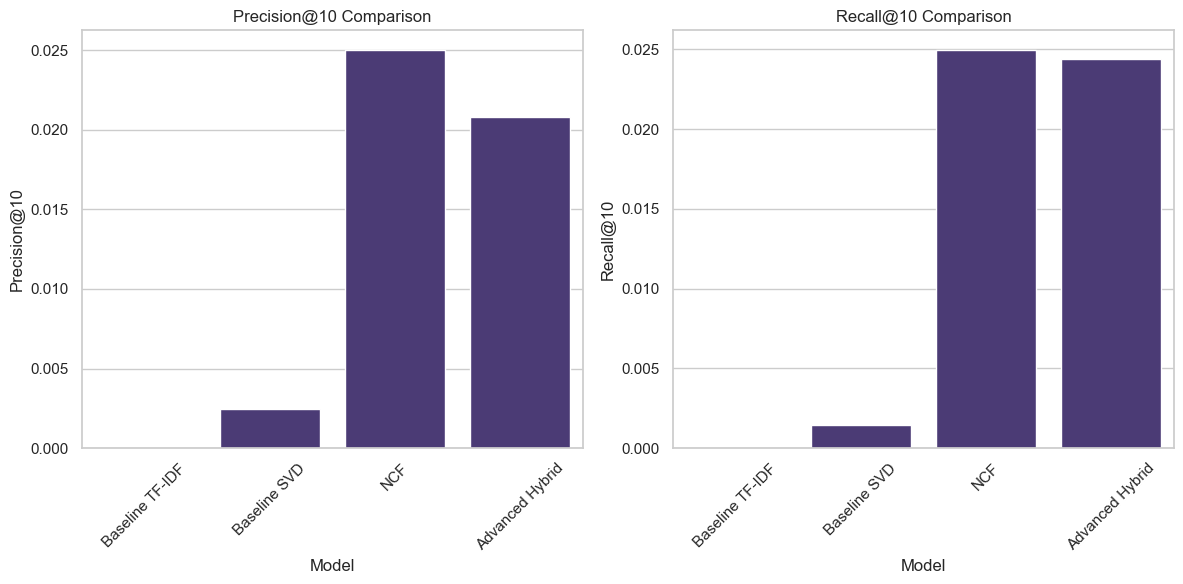

In [23]:
# Visualize results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='Precision@10')
plt.title('Precision@10 Comparison')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='Recall@10')
plt.title('Recall@10 Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Save results
results_df.to_csv('../data/cleaned/advanced_evaluation_results.csv', index=False)

In [27]:
# Save hybrid model components
hybrid_package = {
    'meta_learner': meta_learner,
    'sbert_model': sbert_model,
    'sbert_embeddings': sbert_embeddings,
    'ncf_model': ncf_model.state_dict(),
    'user_map': user_map,
    'item_map': item_map,
    'reverse_item_map': reverse_item_map,
    'bundle_info': bundle_info
}
with open('../models/advanced_hybrid_model.pkl', 'wb') as f:
    pickle.dump(hybrid_package, f)